In [9]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# notebook は EXP011/notebook/ にあるので親2つ上がプロジェクトルート
ROOT = Path().resolve().parents[1]
print(f"Project root: {ROOT}")

Project root: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History


In [10]:
# ---- 設定 ----------------------------------------------------------------
bank_id = 1
prior   = "normal"

results_dir = ROOT / "EXP011" / "results"
mfi_path    = ROOT / "EXP007" / "results" / f"summary_uncor_{bank_id}_MFI.csv"

# EXP011/results/ に存在する全 gamma の DQN summary を収集
pattern = re.compile(rf"summary_uncor_{bank_id}_DQN_{prior}_gamma_(.+)\.csv")
gamma_files = {
    pattern.match(p.name).group(1): p
    for p in sorted(results_dir.glob(f"summary_uncor_{bank_id}_DQN_{prior}_gamma_*.csv"))
    if pattern.match(p.name)
}

print(f"Found gamma values: {list(gamma_files.keys())}")

mfi = pd.read_csv(mfi_path)
print(f"MFI loaded: {mfi_path}")


Found gamma values: ['0.1', '0.3', '0.9']
MFI loaded: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP007/results/summary_uncor_1_MFI.csv


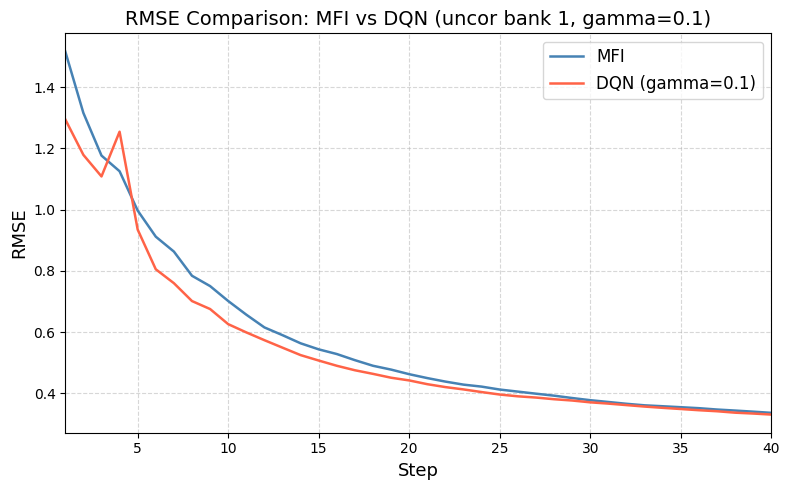

Saved to /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP011/results/rmse_comparison_uncor_1_gamma_0.1.png


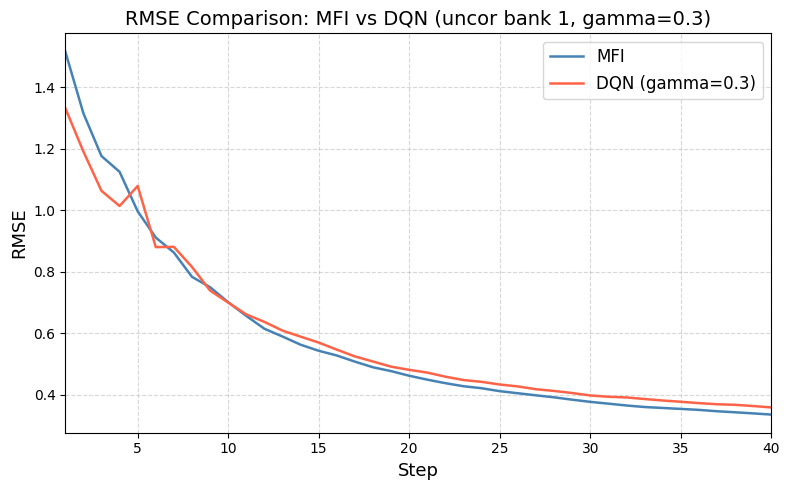

Saved to /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP011/results/rmse_comparison_uncor_1_gamma_0.3.png


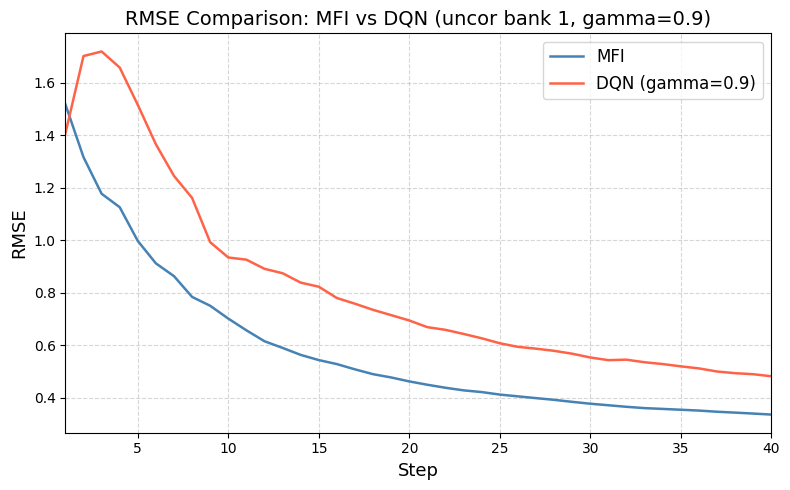

Saved to /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP011/results/rmse_comparison_uncor_1_gamma_0.9.png


In [11]:
out_dir = results_dir
out_dir.mkdir(parents=True, exist_ok=True)

for gamma, path in gamma_files.items():
    dqn = pd.read_csv(path)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(mfi["step"], mfi["RMSE"], label="MFI", color="steelblue", linewidth=1.8)
    ax.plot(dqn["step"], dqn["RMSE"], label=f"DQN (gamma={gamma})", color="tomato", linewidth=1.8)

    ax.set_xlabel("Step", fontsize=13)
    ax.set_ylabel("RMSE", fontsize=13)
    ax.set_title(f"RMSE Comparison: MFI vs DQN (uncor bank {bank_id}, gamma={gamma})", fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_xlim(1, dqn["step"].max())

    plt.tight_layout()

    out_path = out_dir / f"rmse_comparison_uncor_{bank_id}_gamma_{gamma}.png"
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved to {out_path}")
